<>:73: SyntaxWarning: invalid escape sequence '\g'
<>:83: SyntaxWarning: invalid escape sequence '\g'
<>:73: SyntaxWarning: invalid escape sequence '\g'
<>:83: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_600/173523036.py:73: SyntaxWarning: invalid escape sequence '\g'
  f"($\gamma$={gamma}, J={J}, L={L}, samples={samples})")
/tmp/ipykernel_600/173523036.py:83: SyntaxWarning: invalid escape sequence '\g'
  f"($\gamma$={gamma}, J={J}, L={L}, samples={samples})")


Simulating K0 = 0.1 ...
Simulating K0 = 0.2 ...
Simulating K0 = 0.3 ...
Simulating K0 = 0.4 ...
Simulating K0 = 0.5 ...
All simulations done.


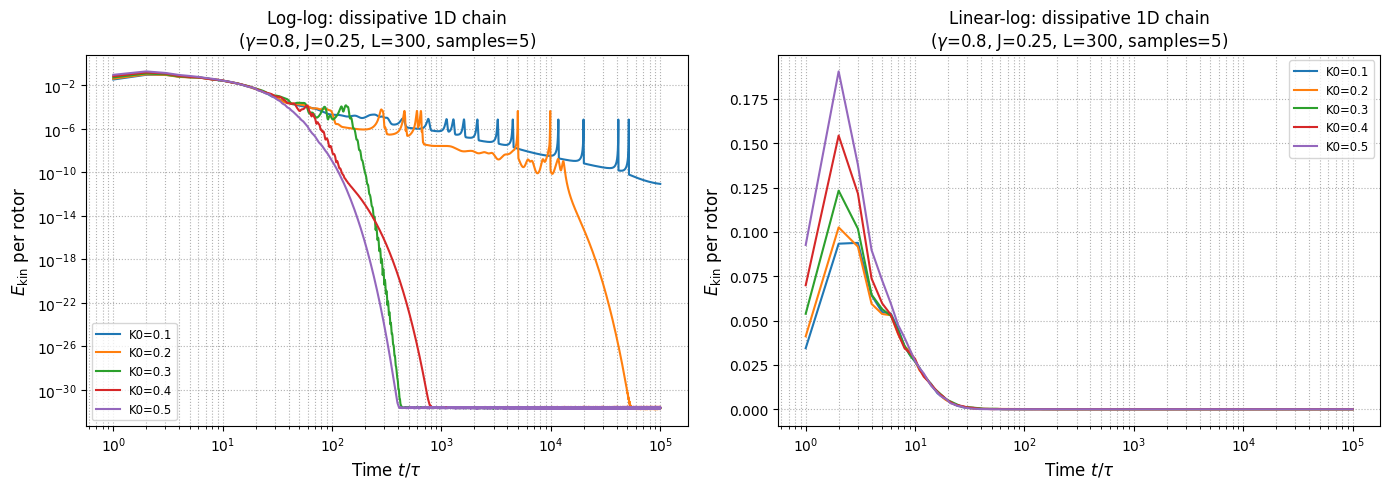

Plot saved.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------
# Parameters
# -----------------------------------------------
L         = 300      # chain length
tau       = 1.0      # time step (one kick period)
gamma     = 0.8      # damping coefficient (1-gamma = dissipation rate)
J         = 0.25     # nearest-neighbour interaction strength
timesteps = 100000   # total kicks
samples   = 5        # ensemble realizations

# K0 values to scan
K0_list = [0.1, 0.2, 0.3, 0.4, 0.5]


def simulate_dissipative_1d(K0, L, gamma, J, timesteps):
    theta = np.random.uniform(0, 2 * np.pi, L)
    p     = np.zeros(L)

    E_kin = np.zeros(timesteps)

    for t in range(timesteps):
        # Nearest-neighbour angle differences (periodic BC)
        theta_right = np.roll(theta, -1)   # theta_{i+1}
        theta_left  = np.roll(theta,  1)   # theta_{i-1}

        # Momentum update
        p = (gamma * p
             - K0 * np.sin(theta)
             + J  * (np.sin(theta - theta_right) + np.sin(theta - theta_left)))

        # Angle update
        theta = (theta + p) % (2 * np.pi)

        # Kinetic energy per rotor
        E_kin[t] = np.mean(0.5 * p**2)

    return E_kin


# -----------------------------------------------
# Run simulations
# -----------------------------------------------
time_array = np.arange(1, timesteps + 1)
results = {}

for K0 in K0_list:
    print(f"Simulating K0 = {K0} ...")
    E_accum = np.zeros(timesteps)
    for s in range(samples):
        E_accum += simulate_dissipative_1d(K0, L, gamma, J, timesteps)
    results[K0] = E_accum / samples

print("All simulations done.")

# -----------------------------------------------
# Plot
# -----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for K0 in K0_list:
    axes[0].plot(time_array, results[K0], label=f"K0={K0}")
    axes[1].plot(time_array, results[K0], label=f"K0={K0}")

# Left panel: log-log (direct analogue of Rajak Fig. 2)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"Time $t/\tau$", fontsize=12)
axes[0].set_ylabel(r"$E_{\rm kin}$ per rotor", fontsize=12)
axes[0].set_title(f"Log-log: dissipative 1D chain\n"
                  f"($\gamma$={gamma}, J={J}, L={L}, samples={samples})")
axes[0].legend(fontsize="small")
axes[0].grid(True, which="both", ls=":")

# Right panel: linear-log (plateau saturation clearer)
axes[1].set_xscale("log")
axes[1].set_yscale("linear")
axes[1].set_xlabel(r"Time $t/\tau$", fontsize=12)
axes[1].set_ylabel(r"$E_{\rm kin}$ per rotor", fontsize=12)
axes[1].set_title(f"Linear-log: dissipative 1D chain\n"
                  f"($\gamma$={gamma}, J={J}, L={L}, samples={samples})")
axes[1].legend(fontsize="small")
axes[1].grid(True, which="both", ls=":")

plt.tight_layout()
plt.savefig("dissipative_prethermal_1d.png", dpi=150)
plt.show()
print("Plot saved.")